DEBUG:cmdstanpy:input tempfile: /tmp/tmpq6f0sh96/4cc9xlvc.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq6f0sh96/rvq3r3ne.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=49127', 'data', 'file=/tmp/tmpq6f0sh96/4cc9xlvc.json', 'init=/tmp/tmpq6f0sh96/rvq3r3ne.json', 'output', 'file=/tmp/tmpq6f0sh96/prophet_model2mn3f7xo/prophet_model-20250726060954.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:09:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:10:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


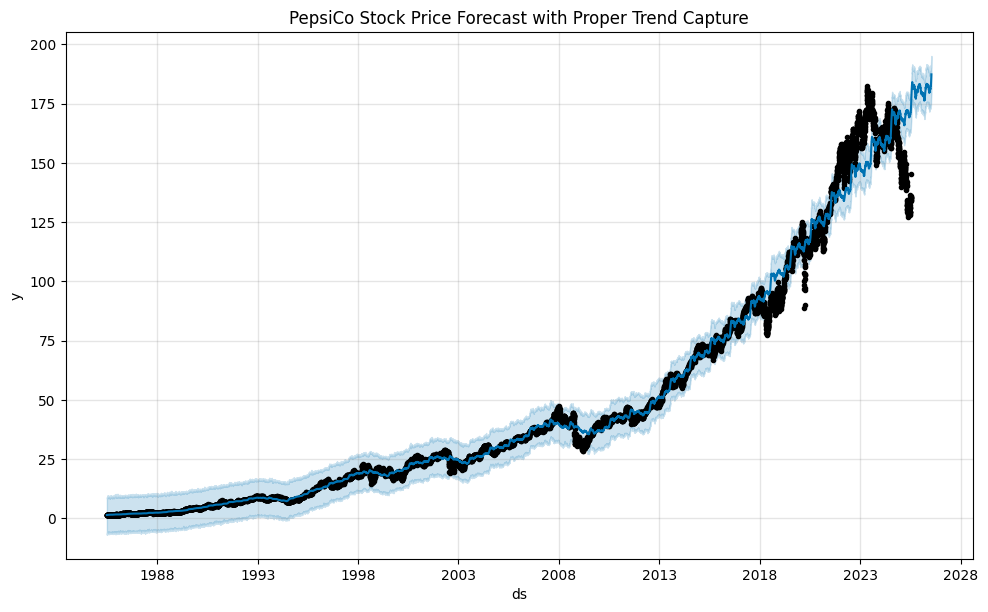

In [16]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. Prepare Data Correctly
# Ensure your dataframe has exactly 'ds' (dates) and 'y' (values) columns
df = pd.read_csv('/content/drive/MyDrive/Datasets/PEPSICO_stock_data.csv').rename(columns={
    'Date': 'ds',
    'Close': 'y'
})

# Remove rows with NaN in 'ds' column
df.dropna(subset=['ds', 'y'], inplace=True)

# Convert 'ds' to datetime objects
df['ds'] = pd.to_datetime(df['ds'])


# 2. Configure Prophet with Proper Settings
model = Prophet(
    growth='linear',           # Try 'logistic' if exponential growth
    changepoint_prior_scale=0.5,  # More sensitive to changes (default 0.05)
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,  # Stocks often don't have weekly patterns
    daily_seasonality=False,
    holidays=None
)

# 3. Add Custom Seasonality (if needed)
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# 4. Fit Model with Log Transform if Needed
model.fit(df)  # Uncomment if exponential growth

# 5. Create Future Dataframe
future = model.make_future_dataframe(periods=365, freq='D')

# 6. Make Prediction
forecast = model.predict(future)

# 7. Plot Results
fig = model.plot(forecast)
plt.title('PepsiCo Stock Price Forecast with Proper Trend Capture')
plt.show()